# Practical Python Solution

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm

In [2]:
df = pd.read_csv("loan_applications.csv")

df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status
0,CUST1001,56,38210,702950,322,24,Yes
1,CUST1002,34,144610,99486,623,36,No
2,CUST1003,27,113781,788625,513,24,Yes
3,CUST1004,47,115192,90045,827,24,No
4,CUST1005,25,22725,83190,853,36,No


In [6]:
df.info()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer_ID     5000 non-null   object
 1   Age             5000 non-null   int64 
 2   Income          5000 non-null   int64 
 3   Loan_Amount     5000 non-null   int64 
 4   Credit_Score    5000 non-null   int64 
 5   Loan_Term       5000 non-null   int64 
 6   Default_Status  5000 non-null   object
dtypes: int64(5), object(2)
memory usage: 273.6+ KB


,Age,Income,Loan_Amount,Credit_Score,Loan_Term
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.562600,85060.670800,419665.781800,597.960600,35.661600
std,11.663417,37782.366674,217527.111805,173.403686,16.949352
min,21.000000,20024.000000,50022.000000,300.000000,12.000000
25%,30.000000,52421.250000,229588.250000,448.000000,24.000000
50%,41.000000,85301.000000,419463.000000,593.000000,36.000000
75%,51.000000,118170.750000,605763.500000,748.000000,48.000000
max,60.000000,149999.000000,799952.000000,900.000000,60.000000


In [7]:
df.isnull().sum()

Customer_ID       0
Age               0
Income            0
Loan_Amount       0
Credit_Score      0
Loan_Term         0
Default_Status    0
dtype: int64

In [ ]:
# Mean, Median, Mode of Income

mean_income = df['Income'].mean()
median_income = df['Income'].median()
mode_income = df['Income'].mode()[0]

print("Mean Income:", mean_income)
print("Median Income:", median_income)
print("Mode Income:", mode_income)

Mean Income: 85060.6708
Median Income: 85301.0
Mode Income: 41111


In [10]:
# Range, Variance, Standard Deviation of Loan Amount

loan_range = df['Loan_Amount'].max() - df['Loan_Amount'].min()

loan_variance = df['Loan_Amount'].var()

loan_std = df['Loan_Amount'].std()

print("Range:", loan_range)
print("Variance:", loan_variance)
print("Standard Deviation:", loan_std)

Range: 749930
Variance: 47318044370.43828
Standard Deviation: 217527.1118054903


In [11]:
# Probability of Loan Default

default_probability = (df['Default_Status'] == 'Yes').mean()

print("Probability of Default:", default_probability)

Probability of Default: 0.4846


In [12]:
# Contingency Table

# Create Credit Score Categories

df['Credit_Category'] = pd.cut(
    df['Credit_Score'],
    bins=[300, 600, 750, 900],
    labels=['Low', 'Medium', 'High']
)

contingency_table = pd.crosstab(
    df['Credit_Category'],
    df['Default_Status']
)

print(contingency_table)

Default_Status     No   Yes
Credit_Category            
Low               714  1823
Medium            827   399
High             1034   196


In [13]:
# Probability of default when Credit Score < 600

low_credit = df[df['Credit_Score'] < 600]

conditional_probability = (
    (low_credit['Default_Status'] == 'Yes').mean()
)

print("Conditional Probability:", conditional_probability)

Conditional Probability: 0.7191807798345805


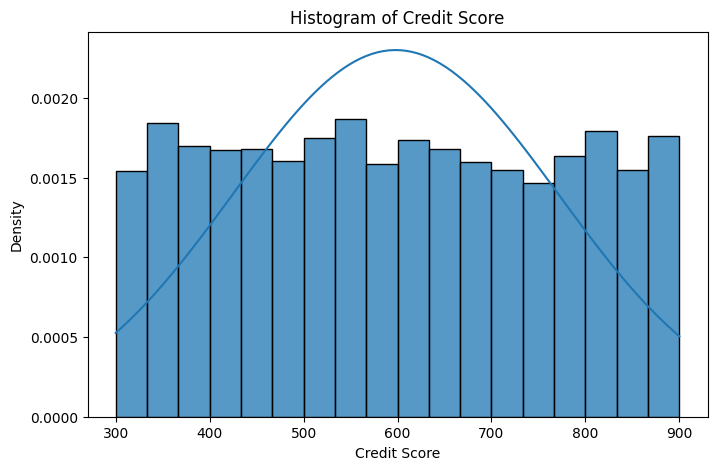

In [14]:
# Histogram with Gaussian Curve

plt.figure(figsize=(8,5))

sns.histplot(df['Credit_Score'], kde=False, stat='density')

mu = df['Credit_Score'].mean()
sigma = df['Credit_Score'].std()

x = np.linspace(
    df['Credit_Score'].min(),
    df['Credit_Score'].max(),
    100
)

plt.plot(x, norm.pdf(x, mu, sigma))

plt.title("Histogram of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Density")

plt.show()

In [15]:
# Skewness and Kurtosis

skewness = df['Loan_Amount'].skew()

kurtosis = df['Loan_Amount'].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: 0.029463499012439325
Kurtosis: -1.216138672714041


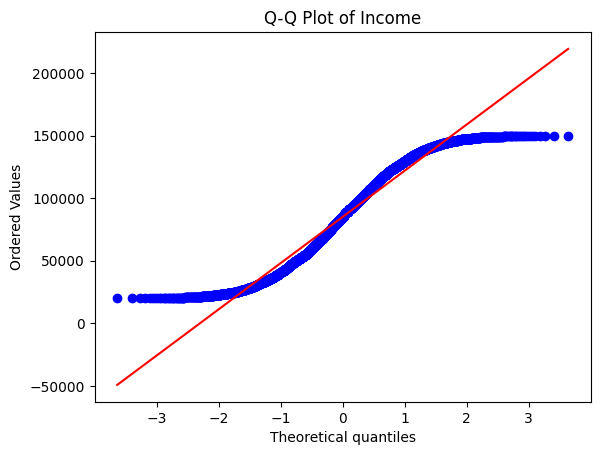

In [16]:
# Q-Q Plot

stats.probplot(df['Income'], dist="norm", plot=plt)

plt.title("Q-Q Plot of Income")

plt.show()

In [17]:
# Linear Algebra Application
# Create Vectors

vectors = df[['Income', 'Loan_Amount']].head()

print(vectors)

   Income  Loan_Amount
0   38210       702950
1  144610        99486
2  113781       788625
3  115192        90045
4   22725        83190


In [18]:
# Dot Product

v1 = vectors.iloc[0].values
v2 = vectors.iloc[1].values

dot_product = np.dot(v1, v2)

print("Dot Product:", dot_product)

Dot Product: 75459231800


In [19]:
#  Norm of Vector

norm_v1 = np.linalg.norm(v1)

print("Norm of Vector:", norm_v1)

Norm of Vector: 703987.7176485397


In [20]:
# Angle Between Two Vectors

cos_theta = dot_product / (
    np.linalg.norm(v1) * np.linalg.norm(v2)
)

angle = np.arccos(cos_theta)

angle_degree = np.degrees(angle)

print("Angle in Degrees:", angle_degree)

Angle in Degrees: 52.362211668185786


# Part A

## 1. Explain Mean, Median, Mode in the context of customer income.

Mean is the average income of all customers.
Median is the middle income value after arranging all incomes in order.
Mode is the income value that appears most frequently in the dataset.



## 2. Differentiate between Standard Deviation and Variance using loan amounts.

Variance measures how much loan amounts are spread from the average value.
Standard deviation is the square root of variance and shows spread in a simpler form.



## 3. What is a Random Variable? Give one example from the dataset.

A random variable is a variable whose value changes randomly.
Example: Customer income or loan amount in the dataset.



## 4. Explain Conditional Probability in terms of loan defaults.

Conditional probability means finding the probability of an event under a condition.
Example: Probability of loan default when credit score is below 600.



## 5. Define Bayes Theorem and mention how banks can apply it.

Bayes theorem is used to calculate probability using prior information.
Banks use it to predict loan default risk and detect fraud customers.



## 6. Differentiate between Empirical Probability and Theoretical Probability with examples.

Empirical probability is based on actual observed data.
Theoretical probability is based on mathematical calculations.
Example: Loan default data is empirical, coin toss probability is theoretical.



## 7. What is a Poisson Distribution? Give a business example.

Poisson distribution measures the probability of events occurring in a fixed time period.
Example: Number of loan defaults occurring in one day in a bank.



## 8. Write a short note on Eigenvalues and Eigenvectors in data analysis.

Eigenvectors show the important directions of data.
Eigenvalues show how much importance or variance exists in those directions.
They are used in PCA and machine learning.
